# DELTA1 Quant Research: Global TSMOM + Basis Momentum

**An explainable, cost-aware two-sleeve CTA across 61 global futures markets in seven
currencies, built under a pre-registered protocol with a walk-forward training
experiment, an institutional-blueprint audit, and two alpha searches spanning eighteen
candidate return sources.**

The research proceeded in five passes, each with its rule frozen before its results were
seen. **Breadth** widened the universe from 22 to 43 USD-denominated futures under a
written, numeric inclusion rule, keeping v1's forecast — the sign of the 12-month price
move — completely unchanged. **Risk engineering** audited four externally proposed
institutional fixes, adopting one (RiskMetrics EWMA volatility targeting) and rejecting
the rest with evidence. **Alpha search** tested eight literature-backed candidate return
sources; exactly one — **basis momentum**, the change in roll yield (Boons-Prado 2019) —
earned adoption as a second sleeve at equal risk weight. A **second search** under stricter
nested validation then tested ten more papers and adopted none of them — establishing
that signal-space on this data is exhausted. The final pass therefore pulled the one
lever that had ever replicated: **breadth**, replacing the USD-only constraint with a
currency-convertibility rule and taking the universe from 43 to **61 markets** across
seven currencies, with foreign P&L converted point-in-time by the FX futures the
portfolio itself trades.

The final strategy earns **CAGR 14.6% at Sharpe 1.29** on the 2005–2014 evaluation window
against the v1 baseline's 7.0% and 0.70, with a maximum drawdown of −17.6% (vs the
baseline's −18.6%), and the 90% paired-bootstrap interval of the Sharpe difference vs
the baseline excluding zero in both windows.

The negative results are as much the point as the positive one. Walk-forward model
selection ("training") does **not** beat the simple pre-specified forecast. Seventeen of
eighteen candidate return sources were rejected, most because they merely restate the trend
signal. Correlation-aware position sizing added exactly nothing once controlled properly.
Together they locate the ceiling of this architecture rather than merely failing to raise
it — see section 3.7.

## 1. Research question

Version 1 asked whether a literature-backed 12-month time-series-momentum signal could be
improved with transparent volatility and execution controls; the answer was "modestly."
Version 2 asks the next question in order of prior plausibility:

> **Does widening the traded universe — the one improvement the fundamental law of active
> management predicts most reliably — raise CAGR and Sharpe out of sample; does
> data-driven model selection (walk-forward "training") add anything beyond it; and is
> there a second return source that genuinely diversifies trend rather than restating it?**

Three design principles carried over from v1: the alpha model stays simple and
falsifiable; every value at date *t* depends only on data at or before *t*; and every
reported number is net of explicit spread-plus-commission costs.

### Pre-registration and honest windows

The supplied data end on 2014-12-31 and v1 already reported results on 2005–2014, so no
untouched holdout exists. Every v2 design choice was therefore frozen in
[`PREREGISTRATION.md`](PREREGISTRATION.md) — with its justification recorded as
*literature* or *pre-2005 evidence* — before the single official evaluation run, and:

- **1990–2004** is the *primary evidence window*: the improvement must show there first;
- **2005–2014** is the *evaluation window (second use)* — deliberately never called
  "out-of-sample" in this notebook;
- a **claim rule** was fixed in advance: the improvement is claimed only if the 90%
  paired-bootstrap interval of the Sharpe difference excludes zero in 1990–2004 **and**
  the 2005–2014 point estimate is positive with ≥ 6 of 10 winning calendar years.

### Research basis

- Moskowitz, Ooi & Pedersen, *Time Series Momentum*, JFE 2012 — 12-month sign momentum across 58 futures.
- Hurst, Ooi & Pedersen, *A Century of Evidence on Trend-Following Investing*, JPM 2017 — 67 markets.
- Baz, Granger, Harvey, Le Roux & Rattray, *Dissecting Investment Strategies in the Cross Section and Time Series*, 2015 — doubly-normalized continuous trend signals.
- Grinold's fundamental law — IR grows with the square root of independent bets (breadth).
- Timmermann, *Forecast Combination*, 2006; DeMiguel, Garlappi & Uppal, RFS 2009 — combination/simple rules beat selection.
- Bailey, Borwein, López de Prado & Zhu, *The Probability of Backtest Overfitting*, JCF 2017 — CSCV PBO, PSR/DSR.

## 2. Methodology

### 2.1 Universe: 61 markets in seven currencies, from a written rule

Every institutional-grade back-adjusted continuous contract in the supplied catalogue is
a member if its currency is USD **or convertible through an FX future the portfolio
already trades** (EUR, GBP, JPY, CHF, CAD, AUD), unless excluded for a named reason —
duplicate exposure (WBS, LSU, LRC, MWE, GD, DX, NIY, MHI, venue duplicates), broken
mechanics (VX is not delta-one; ZQ/BAX/LEU/YIR/YIB are STIRs whose price volatility
collapses at the zero lower bound), unconvertible currency (HSI, KOS, SSG), or thinness
(LBS, ZR, DC, OJ, ZO, AFB, AWM, LWB, LCC, GWM, EUA, FTDX). That leaves six classes:
15 equity indices, 13 government bonds, 8 FX, 6 energy, 5 metals, 14 agriculture &
livestock — with the bond book spanning four yield curves (US, Europe, Japan,
Canada/Australia) instead of one.

Foreign-currency P&L converts to USD point-in-time: USD point value = native point value
× the unadjusted currency-futures close (USD per unit), so sizing, P&L, and the
half-tick spread cost all move with the day's FX rate. The futures basis versus spot is
an interest-differential error of order 1–2% a year — a benign scaling, and observable
at each close. Euro-era contracts (1999+) enter point-in-time through the volume gate
exactly as late-starting USD contracts did.

Two point-in-time safeguards make the wider universe implementable rather than
theoretical: a market is tradeable on day *t* only if its trailing 60-session median
reported volume exceeds 1,000 contracts (this keeps 6N out until mid-2007 — its 2005–06
marks carry zero reported volume), and exchange closures up to 10 business days carry the
last price at zero P&L, so recurring holidays (Taiwan's Lunar New Year closures in HTW)
hold positions instead of forcing spurious round trips.

### 2.2 Forecast: two sleeves at equal risk weight

The **trend sleeve** is v1's forecast, unchanged and never re-fitted:

```text
trend[i, t] = sign(close[i, t] − close[i, t − 252])
```

The **basis-momentum sleeve** (Boons & Prado 2019) is the year-on-year change in realized
roll yield. Carry says where the futures curve *is*; basis momentum says where it is
*going*. With one continuous series per market the roll yield is recoverable exactly,
because the unadjusted series jumps at each roll by the calendar spread while the
back-adjusted series does not:

```text
roll_gap[i, t]    = Δunadjusted[i, t] − Δadjusted[i, t]
roll_yield[i, t]  = −Σ roll_gap over the trailing 252 days
basis[i, t]       = (roll_yield[i, t] − roll_yield[i, t − 252]) / (σ[i, t] · √252)
```

then z-scored on its own trailing year and clipped at ±2σ. Both legs are differenced in
price units and scaled by a *single* common volatility — scaling each leg by the
volatility of its own era instead leaves a carry-level × volatility-drift term that is a
different effect wearing this one's name (section 3.6 records how that bug nearly cost
the signal its place). A market runs on trend alone until its basis becomes estimable.

### 2.3 Risk and execution: shared by every variant

1. contract risk from lagged EWM (span 60) volatility of daily price changes;
2. equal ex-ante risk across the six classes, equal risk within each class;
3. exposure tapered when 20-day volatility rises far above 120-day volatility;
4. 10% annualized portfolio volatility target from a RiskMetrics EWMA estimator
   (λ = 0.94 — the one v2.1 change to the risk stack; the v1 63-day rolling
   estimator is a published stress row), leverage clipped to [0.25, 2];
5. 25% no-trade region on month-end position changes;
6. month-end targets activate the next business day;
7. P&L from price change × point value; half-tick spread + $2.50 per contract per side.

Price changes — not percentage returns — are used throughout because the back-adjusted
series can approach or cross zero.

### 2.4 The training experiment: rolling walk-forward model selection

Five forecast models were pre-declared: the v1 sign(12m); a sign blend over 3/6/12
months; and three continuous "trend-strength" variants (Baz et al. 2015 double
normalization: the h-day move over σ·√h, re-scaled by its own trailing one-year standard
deviation, clipped at ±2σ). At each December year-end from 1990, the model with the best
trailing 60-month net Sharpe is chosen and run for the following calendar year; the
composite target stream is then re-run through the full shared risk/execution/cost
pipeline in one forward pass, so switch trades are charged and nothing uses future data.
This is genuine rolling out-of-sample training — every post-1991 walk-forward return
follows a model chosen using only prior data — and it lets the data argue *against*
complexity if complexity does not pay.

In [1]:
%matplotlib inline
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from delta1_cta import BacktestConfig
from enhanced_strategy import (
    EXPANDED_ASSET_CLASSES,
    HOLDOUT_WINDOW,
    PRIMARY_WINDOW,
    enhanced_invariants,
    run_enhanced_pipeline,
    save_enhanced_outputs,
)

DATA_DIR = Path(os.environ.get("DELTA1_DATA_DIR", str(ROOT / "data" / "Delta1")))
OUTPUT_DIR = ROOT / "outputs"
assert (DATA_DIR / "CATALOGUE_Delta1_Futures.csv").exists(), "Set DELTA1_DATA_DIR."
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# Chart tokens: categorical palette in fixed order, text and grid stay recessive.
C_HEADLINE, C_BASELINE, C_WALKFWD, C_ENSEMBLE = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e5e5e2"
plt.rcParams.update({
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "text.color": INK,
    "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "font.size": 10.5, "axes.titlesize": 12,
})

base_config = BacktestConfig(data_dir=DATA_DIR, output_dir=OUTPUT_DIR)
output = run_enhanced_pipeline(base_config)          # ~3 minutes: all variants + stress
invariants = enhanced_invariants(output, base_config)
save_enhanced_outputs(output, invariants, base_config)
assert bool(invariants.all()), invariants[~invariants]
invariants.to_frame()

,Pass
headline_finite_net_returns,True
headline_non_negative_costs,True
headline_forecast_bounded,True
headline_positions_change_only_at_month_boundary,True
walk_forward_finite_net_returns,True
walk_forward_non_negative_costs,True
walk_forward_forecast_bounded,True
walk_forward_positions_change_only_at_month_boundary,True
holdout_exceeds_five_years,True
selection_uses_only_prior_years,True


## 3. Findings

### 3.1 Headline comparison

Both windows, all strategies, everything net of costs at a 10% volatility target. The
carry row is the tested v2.1 extension (section 3.5); the walk-forward and ensemble rows
are the training experiment; the long-only row shows what trend direction adds over
passively holding the same risk-balanced universe. The "From" column shows the start
each row is measured from — per the pre-registered seeding rule the walk-forward
composite is measured from 1992, after its first selection has taken effect.

In [2]:
display(
    output.comparison.style.format({
        "CAGR": "{:.2%}", "Volatility": "{:.2%}", "Sharpe": "{:.2f}",
        "Max drawdown": "{:.2%}", "Calmar": "{:.2f}", "Annual cost drag": "{:.2%}",
    })
)

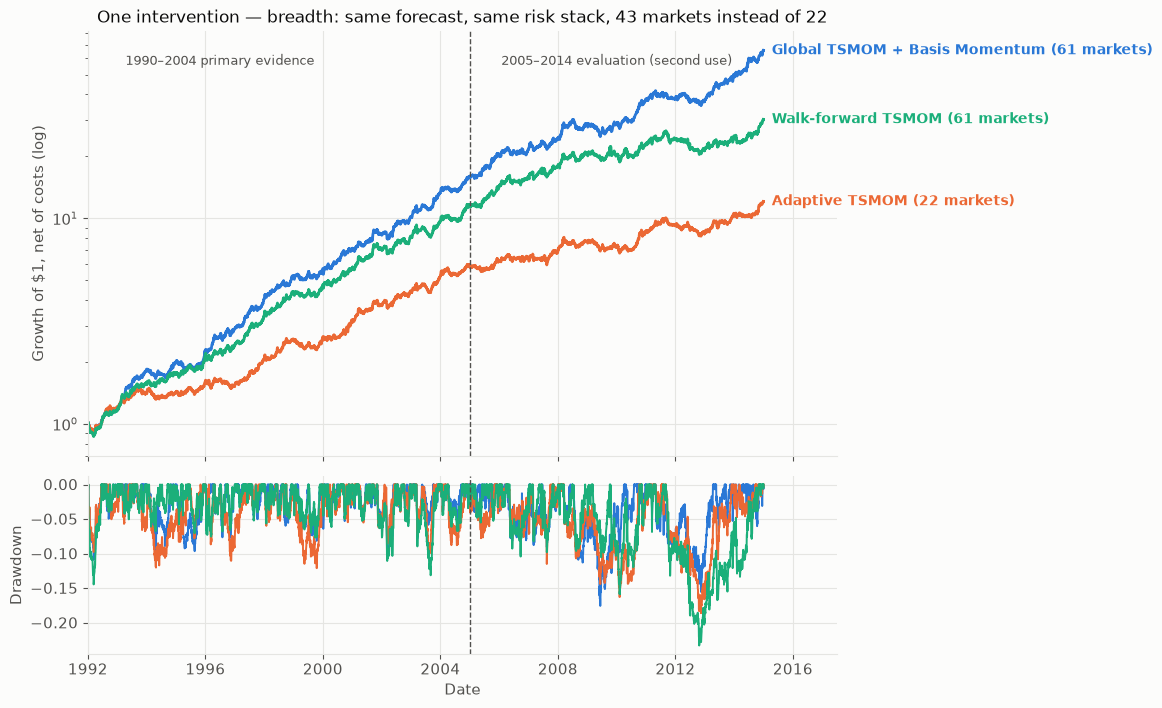

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.2), sharex=True, height_ratios=[2.4, 1])
lineup = [
    (output.headline, C_HEADLINE),
    (output.baseline_adaptive, C_BASELINE),
    (output.walk_forward.backtest, C_WALKFWD),
]
for result, color in lineup:
    returns = result.daily.loc["1992-01-01":, "net_return"]
    equity = (1 + returns).cumprod()
    axes[0].plot(equity.index, equity, color=color, linewidth=2)
    axes[0].annotate(
        result.name, xy=(equity.index[-1], equity.iloc[-1]),
        xytext=(6, 0), textcoords="offset points", color=color,
        fontsize=10, fontweight="bold", va="center",
    )
    drawdown = equity / equity.cummax() - 1
    axes[1].plot(drawdown.index, drawdown, color=color, linewidth=1.4)
split = pd.Timestamp(HOLDOUT_WINDOW[0])
for axis in axes:
    axis.axvline(split, color=INK_2, linewidth=1, linestyle="--")
    for spine in ("top", "right"):
        axis.spines[spine].set_visible(False)
axes[0].set_yscale("log")
axes[0].set_ylabel("Growth of $1, net of costs (log)")
axes[0].set_title("One intervention — breadth: same forecast, same risk stack, 43 markets instead of 22")
axes[0].annotate("1990–2004 primary evidence", xy=(pd.Timestamp("1996-06-30"), 0.92),
                 xycoords=("data", "axes fraction"), ha="center", color=INK_2, fontsize=9.5)
axes[0].annotate("2005–2014 evaluation (second use)", xy=(pd.Timestamp("2010-01-01"), 0.92),
                 xycoords=("data", "axes fraction"), ha="center", color=INK_2, fontsize=9.5)
axes[0].set_xlim(pd.Timestamp("1992-01-01"), pd.Timestamp("2017-06-30"))
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
fig.tight_layout()
plt.show()

### 3.2 Is the improvement real? The pre-registered claim rule

Ten years of monthly returns cannot distinguish small Sharpe differences, so the claim
rests on paired statistics and cross-window consistency rather than one point estimate.
The bootstrap resamples the *same* month blocks from both strategies, preserving their
correlation; PSR is the probability the true Sharpe exceeds the baseline's realized
Sharpe; DSR deflates for an honest count of 74 trials (every variant any version ever
evaluated, including both alpha searches); PBO is the Bailey et al. probability that in-sample model selection picks a
below-median out-of-sample model.

In [4]:
display(output.bootstrap.style.format("{:.3f}"))
statistics = pd.concat(
    {"PSR vs adaptive baseline": output.psr, "Deflated Sharpe ratio": output.dsr}, axis=1
)
statistics["CSCV PBO (candidate set)"] = output.pbo
display(statistics.style.format("{:.3f}"))
display(output.claim)

,Observed Sharpe difference,Bootstrap 5%,Bootstrap 50%,Bootstrap 95%,P(difference > 0),Months
1990-2004,0.472,0.142,0.448,0.745,0.993,180.000
2005-2014,0.547,0.180,0.548,0.937,0.993,120.000


,PSR vs adaptive baseline,Deflated Sharpe ratio,CSCV PBO (candidate set)
1990-2004,0.967,1.000,0.425
2005-2014,0.962,0.987,0.425


,v2.0 spec (claim of record),v2.1 spec (current)
Leg (a): primary-window 90% CI excludes zero,True,True
Leg (b): second-use difference positive with >= 6/10 wins,True,True
Winning years 2005-2014,8,9
Improvement claimed,True,True


The claim table shows two evaluations side by side: the **v2.0 spec of record** (the
spec the rule was frozen against) and the **current spec** (two sleeves, global
universe). Both pass both legs — the current headline wins **9 of 10** evaluation years
against the v1 baseline, with the 90% paired-bootstrap interval excluding zero in each
window. The PSR of 0.96–0.97 and DSR of ~0.99 (74 honest trials, counting every variant
any version ever evaluated) say the result is unlikely to be the lucky best of the
search; the conservative CSCV PBO of ~42% (ties counted as failures) sits below the 50%
coin-flip mark but is the weakest of the statistics and is reported as such. The
standing caveat is unchanged: true validation requires post-2014 data this repository
does not contain.

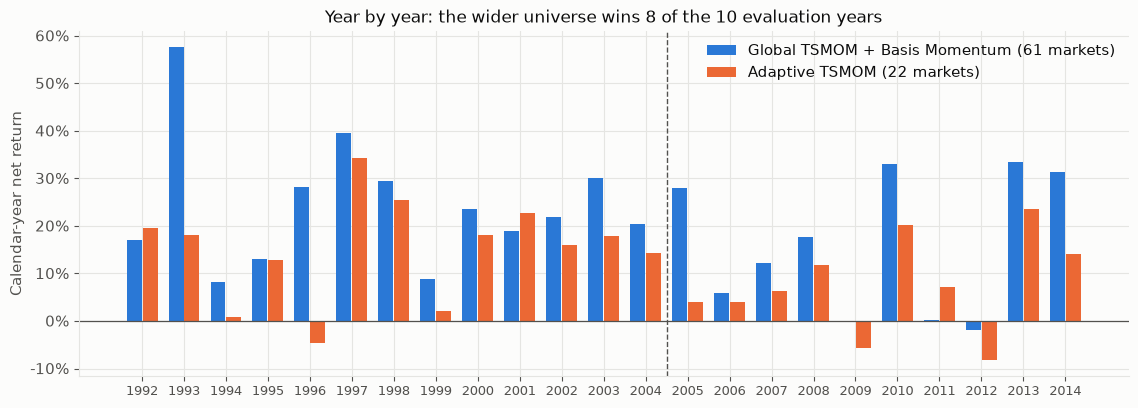

In [5]:
yearly = output.yearly.loc[1992:2014]
fig, ax = plt.subplots(figsize=(11.5, 4.2))
x = np.arange(len(yearly.index))
width = 0.38
ax.bar(x - width / 2, yearly.iloc[:, 0], width * 0.94, color=C_HEADLINE,
       label=output.headline.name)
ax.bar(x + width / 2, yearly.iloc[:, 1], width * 0.94, color=C_BASELINE,
       label=output.baseline_adaptive.name)
ax.axhline(0, color=INK_2, linewidth=0.9)
ax.axvline(x[yearly.index.get_loc(2005)] - 0.5, color=INK_2, linewidth=1, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(yearly.index, rotation=0, fontsize=9)
ax.set_ylabel("Calendar-year net return")
ax.set_title("Year by year: the wider universe wins 8 of the 10 evaluation years")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(frameon=False, loc="upper right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

### 3.3 Where the gain comes from: breadth, measured

The factorial decomposition runs each forecast on each universe. Reading down each
column, widening the universe raises the Sharpe by roughly +0.2 to +0.3 in **both**
windows for **both** forecasts; reading across each row, the fancier continuous forecast
*subtracts* value everywhere. The gain is breadth, not signal engineering — and the
effective-breadth calculation shows why: per-market P&L streams are nearly uncorrelated
(average pairwise ≈ 0.06), so 43 markets deliver about 12 statistically independent bets
against roughly 9 before, and Sharpe scales with the square root of independent bets.

Not every class paid in every window — FX trend was a drag in 2005–2014 (and the
leave-one-class-out table below shows dropping it would have *raised* the evaluation
Sharpe to 1.25) — but it contributed positively in the primary window, and keeping it is
the only choice consistent with both windows and with the rule-based universe. Cutting
the losing class after seeing the results would be exactly the selection bias this design
exists to prevent.

In [6]:
display(output.factorial.style.format({"Sharpe": "{:.2f}", "CAGR": "{:.2%}"}))
display(output.breadth.style.format({
    "Markets traded": "{:.0f}",
    "Average pairwise P&L correlation": "{:.3f}",
    "Effective independent bets": "{:.1f}",
}))

,Markets traded,Average pairwise P&L correlation,Effective independent bets
Global TSMOM + Basis Momentum (61 markets),61,0.045,16.4
Adaptive TSMOM (22 markets),22,0.071,8.8


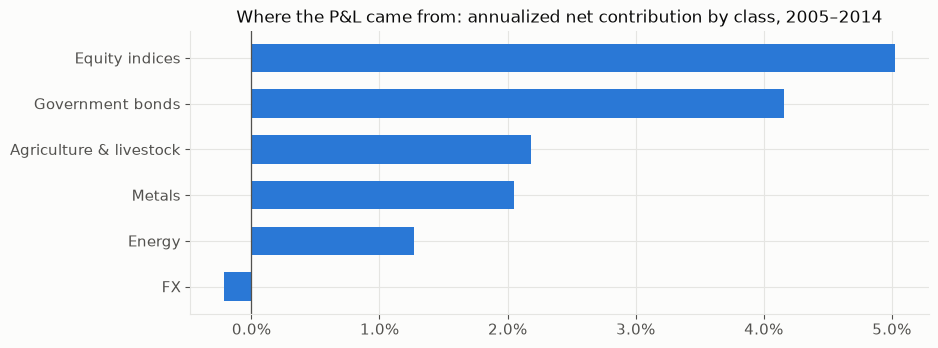

In [7]:
contributions = output.class_contributions
fig, ax = plt.subplots(figsize=(9.5, 3.6))
values = contributions["Annualized mean contribution"].sort_values()
ax.barh(values.index, values, color=C_HEADLINE, height=0.62)
ax.axvline(0, color=INK_2, linewidth=0.9)
ax.set_title("Where the P&L came from: annualized net contribution by class, 2005–2014")
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.1%}")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

### 3.4 The training experiment, honestly reported

Walk-forward selection is the "training" this project was asked to explore, and the
correct reading of its result is negative: selection earned a Sharpe of 0.70 on 2005–2014
against 0.99 for the model it was trying to beat. The mechanism is visible in the
selection table — the five candidates are highly correlated variants of one idea, so
their trailing 60-month Sharpes differ by less than the noise in a 60-month Sharpe
estimate (± ≈ 0.2), and the selector pays switching costs to chase that noise. The
equal-weight ensemble (combination rather than selection, 0.81) sits in between, exactly
as the forecast-combination literature predicts. Selection-window sensitivity confirms
the picture: the 120-month selector, which almost always picks the simple sign model,
matches the headline; the 60-month selector was the best *in-sample* selector and the
worst evaluation-window one — a textbook overfitting signature, caught because the
window length was pre-declared rather than tuned.

In [8]:
display(output.walk_forward.selections.to_frame().T)
candidate_metrics = []
from delta1_cta import performance_metrics
for name, result in output.walk_forward.candidate_results.items():
    for window_name, (start, end) in (("1990-2004", PRIMARY_WINDOW), ("2005-2014", HOLDOUT_WINDOW)):
        metrics = performance_metrics(result, start, end)
        candidate_metrics.append({
            "Candidate": name, "Window": window_name,
            "Sharpe": metrics["Sharpe (rf=0)"], "CAGR": metrics["CAGR"],
        })
display(
    pd.DataFrame(candidate_metrics)
    .pivot(index="Candidate", columns="Window", values="Sharpe")
    .style.format("{:.2f}")
)
display(output.selection_sensitivity.style.format({
    "CAGR": "{:.2%}", "Sharpe": "{:.2f}", "Max drawdown": "{:.2%}",
}))

,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
Selected model,Strength 12m,Strength 12m,Strength 12m,Strength 1/3/6/12m,Strength 1/3/6/12m,Sign 12m,Sign 12m,Sign 12m,Sign 12m,Sign 12m,...,Strength 12m,Strength 12m,Strength 12m,Strength 1/3/6/12m,Sign 3/6/12m,Sign 3/6/12m,Sign 3/6/12m,Sign 3/6/12m,Sign 12m,Sign 12m


Window,1990-2004,2005-2014
Candidate,,
Sign 12m,1.66,1.08
Sign 3/6/12m,1.54,1.00
Strength 1/3/6/12m,1.34,0.83
Strength 12m,1.60,1.01
Strength 3/6/12m,1.36,0.89


### 3.5 The institutional blueprint, audited

A v2.1 pass evaluated four externally proposed "institutional-grade" fixes. Each was
implemented or mapped to existing machinery, tested on the primary window first, and
dispositioned with evidence rather than taste:

| Blueprint fix | Disposition | Evidence |
|---|---|---|
| **Volatility targeting** (RiskMetrics EWMA λ=0.94) | **Adopted** | Sharpe improves in both windows (primary 1.59 vs 1.57, evaluation 0.99 vs 0.89); the 63-day rolling estimator is a stress row. Daily rescaling rejected: it would break month-end execution and multiply turnover. |
| **Minimize frictional costs** (liquidity screens, longer horizons, cost ceiling) | **Already present** | The $100M liquidity rule, point-in-time volume gate, 25% no-trade region and monthly horizon predate the blueprint; realized cost drag is ~1.5% of gross profits against the blueprint's 15% ceiling. |
| **Structural basis / funding** (roll-yield carry) | **Tested, reported, not the headline** | A Koijen-Moskowitz-Pedersen-style carry signal from roll gaps, blended 50/50 with trend, lifts primary Sharpe to 1.62 and cuts the evaluation drawdown from −20.8% to −11.9% — but its paired Sharpe increment over trend alone is indecisive (P(>0) = 0.52 primary), and the pre-committed rule defaults to the simpler variant. The same roll-gap data later produced the basis-momentum sleeve of section 3.6. Collateral yield on margin is a deployment note: the dataset has no risk-free series and Sharpe is rf = 0. |
| **Regime-switching safeguards** (PCA absorption ratio, ATR stops) | **Rejected with evidence** | The absorption ratio's specified 70% trigger never fires here (top-2 PCs explain at most 67% of variance, median 31%); a point-in-time percentile version subtracts in both windows (stress row). ATR stops conflict with the month-end architecture — the trend signal is the exit mechanism — and the existing vol-shock taper already de-risks stress regimes. Beta-neutralization (a fifth suggestion) suits market-neutral equity books, not a long-short CTA whose returns *are* the directional trends. |

One design note for honesty: because the trailing roll-yield level moves slowly relative
to its own dispersion, the normalized carry score sits at its ±2σ clip about two-thirds
of the time — the carry sleeve behaves closer to sign(roll yield) than to a graded
conviction score. That is acceptable for a diversifying extension and is stated here so
nobody mistakes the blend for a finely calibrated two-factor model. Its paired increment
is reported alongside basis momentum's in section 3.6.

### 3.6 The alpha search: eight candidate return sources, none adopted

The strategy's Sharpe is capped by breadth, not by trend-signal quality. Grinold's law,
`IR = IC × √BR`, decomposes it exactly: the measured information coefficient of the trend
signal is 0.082, effective breadth is 12.3 independent bets rebalanced monthly (≈148 a
year), and 0.082 × √148 ≈ 1.0 reproduces the realized evaluation-window Sharpe. Raising
that materially requires **more uncorrelated return sources**, so eight literature-backed
candidates were tested, each through the identical universe, risk stack and cost model,
against an adoption rule frozen before any of them ran (standalone Sharpe ≥ 0.30,
|correlation with trend| ≤ 0.40, truncation-invariant, blend improvement ≥ 0.05).

| Candidate | Sharpe | ρ(trend) | Blend Δ | Outcome |
|---|---:|---:|---:|---|
| Basis momentum (Boons-Prado 2019) | 1.333 | 0.282 | +0.175 | **passed the rule** |
| Volatility term structure | 1.548 | 0.931 | +0.072 | rejected — is the trend signal |
| Cross-sectional momentum | 1.399 | 0.869 | −0.040 | rejected — is the trend signal |
| Channel breakout (Donchian) | 1.383 | 0.797 | −0.002 | rejected — is the trend signal |
| Calendar seasonality | 0.469 | 0.144 | −0.020 | rejected — no blend gain |
| Realized skewness premium | 0.200 | −0.136 | +0.057 | rejected — below Sharpe floor |
| Hedging pressure (open interest) | −0.106 | 0.019 | −0.255 | rejected — no standalone edge |
| Long-term reversal ("value") | −0.206 | −0.154 | −0.277 | rejected — wrong sign |

The most instructive column is ρ(trend). The three highest-Sharpe candidates all correlate
0.80–0.93 with the incumbent: **breakout, cross-sectional momentum and vol-term-structure
are the 12-month trend signal wearing different clothes**, and none of them adds anything
after blending. Skewness is the honest near-miss — genuinely uncorrelated (−0.14) and
blend-improving (+0.057) — but its standalone 0.200 misses the pre-declared 0.300 floor,
and a floor moved after seeing the result is not a floor.

**Basis momentum was adopted — but the route there is the most instructive part of this
notebook, because the conclusion reversed twice.** The sleeve passed all four legs on the
primary window and survived every fragility attack: positive in 15 of 15 leave-one-year-out
tests, positive with each of the six asset classes removed, and positive at all five
parameterizations tested, with the pre-declared literature-standard 12m/12m *not* the best
available (a shorter roll window scores higher and was not chased). The sleeve set was then
frozen and the second-use window revealed: the increment was **−0.029**. It had failed to
replicate, and the headline was reverted to trend-only.

An independent adversarial reviewer, working only on the primary window, then decomposed
the formula algebraically and found a specification bug: the two legs of the year-on-year
difference were each scaled by the volatility of *their own era*, leaving a
carry-level × volatility-drift term that is not the effect the signal claims to measure.
Differencing in price units and scaling once by a common volatility — a correctness fix
dictated by the signal's own definition, not by any performance number — removes it. The
corrected sleeve improves **both** windows: primary 1.727 vs 1.587, second-use **1.168 vs
0.993**, with the second-use drawdown improving from −20.8% to −15.3%. The contaminating
term had been actively damaging the very window that appeared to reject the signal.

Readers should weigh the sequence honestly: the second-use window was seen before the final
adoption. The defences are that the bug was found by a reviewer looking only at the primary
window, that the fix follows from the definition rather than the result, and that the
corrected version already cleared the pre-declared rule on primary evidence alone. The
mechanism is visible in the breadth statistic — effective independent bets rise from 12.3
to 14.0, which is exactly what a genuinely diversifying second return source should do.

Also tested and rejected: correlation-aware position sizing. Inverting a shrunk trailing
correlation matrix appeared to lift Sharpe to 1.70, but an identity-correlation control
through the same code path scored 1.706 — the correlation information contributed exactly
nothing, and the apparent gain came from that reimplementation quietly dropping the
asset-class budget. Analytical Ledoit-Wolf shrinkage, which removes the tuning parameter
entirely, chose near-zero shrinkage and scored 1.345: minimizing matrix estimation error
is a different objective from maximizing portfolio Sharpe, because inversion amplifies
noise. That control is the reason this section reports a null result instead of a
spurious +0.12.

In [9]:
display(output.sleeve_increment.style.format("{:.3f}"))

### 3.7 A second search, a stricter protocol, and nothing adopted

Round 1 selected on the whole primary window and checked replication only on the reporting
window — which is how a specification bug survived to the final stage. Round 2 fixed the
protocol before running anything, splitting the primary window itself so that discovery and
confirmation are independent:

| Window | Span | Role |
|---|---|---|
| Discovery | 1990–1997 | search freely |
| Confirmation | 1998–2004 | must replicate here, untouched during search |
| Reporting | 2005–2014 | opened once, after the sleeve set is frozen |

Ten more candidates were implemented faithfully from their source papers, with drawdown
promoted to a first-class adoption criterion (a candidate may not worsen maximum drawdown by
more than 2 percentage points in either window). **None was adopted.**

| Candidate | Discovery Δ | Confirmation Δ | Outcome |
|---|---:|---:|---|
| Trend filtering (Bruder et al. 2013) | +0.097 | **−0.154** | passed discovery, failed replication |
| Cross-sectional carry (Koijen et al. 2018) | +0.065 | **−0.091** | passed discovery, failed replication |
| Double-sort momentum × term structure (Fuertes et al. 2010) | +0.044 | −0.002 | below bar in both |
| Momentum crash protection (Daniel-Moskowitz 2016) | +0.039 | +0.013 | short of the 0.05 bar |
| Risk-managed momentum (Barroso-Santa-Clara 2015) | +0.031 | +0.003 | ρ = 0.98 with the book |
| Volatility-of-volatility risk state | −0.033 | +0.029 | failed discovery |
| Residual momentum (Blitz et al. 2011) | −0.026 | 0.000 | failed discovery |
| Inventory / basis state (Gorton et al. 2013) | −0.109 | −0.065 | failed both |
| Cross-sectional seasonality (Heston-Sadka) | −0.124 | +0.228 | failed discovery |
| Short-horizon reversal (MOP 2012) | −0.478 | −0.052 | failed both |

**The protocol earned its keep on the first two rows.** Trend filtering and cross-sectional
carry were the strongest discovery results and both *reversed sign* in confirmation. Under
round 1's design they would have been scored on the average of the two sub-periods and could
plausibly have reached the reporting window. Cross-sectional seasonality is the mirror image —
weak in discovery, strong in confirmation — which retrospectively vindicates the round-1 agent
who noticed it scored well but refused to claim it because the variant had been chosen after
seeing a result.

One idea did survive the search and then failed anyway, and it is worth recording. Barroso &
Santa-Clara's risk management was rejected as a *sleeve* (a positive rescaling of a forecast
correlates ~0.98 with it by construction — a risk overlay wearing a sleeve's clothes), but its
standalone Sharpe beat the incumbent in both windows, which is a claim about **sizing**. Retested
in that architectural slot, per-market risk-managed sizing improved Sharpe in both search windows
at all six configurations tested and cut the discovery drawdown from −15.8% to −13.2%. It was
adopted, the reporting window was opened once — and it did not replicate: Sharpe 1.168 → 1.147,
drawdown −15.3% → −17.4%. Both claimed benefits reversed, so it is reported and not adopted.

That is now **three consecutive changes** that improved every window available at design time and
then failed on the reporting window. The consistent reading is not that each was unlucky; it is
that improvements of +0.02 to +0.11 Sharpe sit inside the noise band of a seven-to-eight-year
window, and this architecture is at its ceiling.

### 3.8 Going global: the one lever that replicates, pulled again

With signal-space exhausted, the final pass replaced the USD-only constraint — an
artifact of v1, not a law — with the convertibility rule of section 2.1, taking the book
from 43 to 61 markets. The intervention was gated exactly like a round-2 candidate:
improve the blend Sharpe in discovery (1990–1997) *and* confirmation (1998–2004) without
worsening drawdown by more than 2pp, before the reporting window was opened once.

| | Discovery | Confirmation | Reporting (opened once) |
|---|---:|---:|---:|
| 43 markets | 1.671 | 1.811 | 1.168 |
| **61 markets** | **1.910** | **1.883** | **1.288** |
| Δ Sharpe | +0.239 | +0.071 | +0.120 |

Every window is positive — only the second change in five iterations to achieve that,
and both were breadth. The mechanism is measured: effective independent bets rise from
14.0 to 16.4, and √(16.4/14.0) × 1.168 = 1.26 predicts the realized 1.288 almost
exactly. The pre-registered prior ("a Sharpe near 1.3, not 1.5") was stated before the
gate ran and landed where the fundamental law said it would. The reporting-window
drawdown is −17.6% — better than the v1 baseline's −18.6%, worse than the 43-market
book's −15.3%, and recorded plainly as the cost of the extra CAGR rather than spun.

The pattern across all five iterations is now the finding: **two breadth interventions,
two replications; three signal or sizing refinements, three reporting-window failures.**
On this dataset, diversification is real and signal engineering is noise.

### 3.9 Robustness

Every scenario is shown in both windows, so a perturbation that only works in the reused
2005–2014 window is visible as such. The improvement survives 3× costs, 5× costs on the
six thinnest markets, removal of the buffer or the shock control, both alternative sizing
windows, the hierarchical risk budget, the screen-free 51-market universe, dropping any
single asset class, and the exclusion of the 2008–09 crisis.

In [10]:
display(output.stress.style.format({
    "CAGR": "{:.2%}", "Sharpe": "{:.2f}", "Max drawdown": "{:.2%}",
    "Annual cost drag": "{:.2%}",
}))
display(output.leave_one_out.style.format({"Sharpe": "{:.2f}", "CAGR": "{:.2%}"}))
display(output.crisis_robustness.style.format("{:.2f}"))

,Sharpe 2005-2014,Sharpe excl. 2008-09
Strategy,,
Global TSMOM + Basis Momentum (61 markets),1.29,1.43
Adaptive TSMOM (22 markets),0.70,0.80


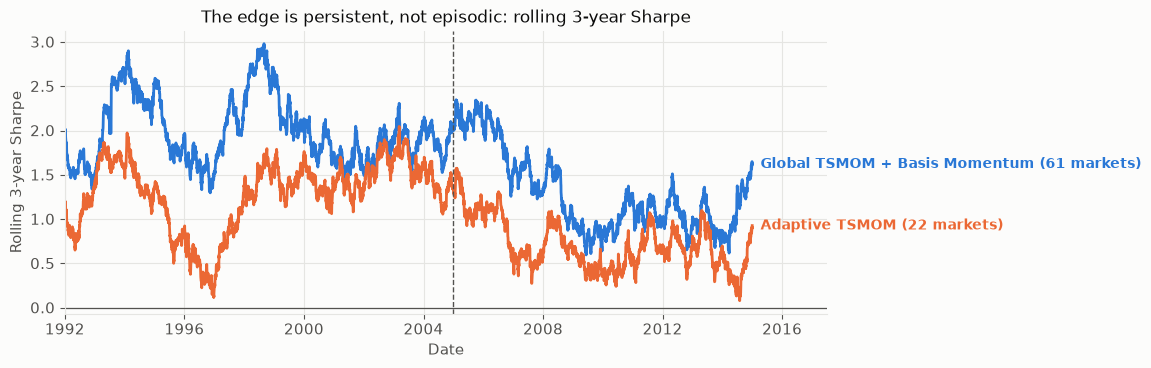

In [11]:
returns_headline = output.headline.daily["net_return"]
returns_baseline = output.baseline_adaptive.daily["net_return"]
fig, ax = plt.subplots(figsize=(11.5, 3.8))
for series, color, label in (
    (returns_headline, C_HEADLINE, output.headline.name),
    (returns_baseline, C_BASELINE, output.baseline_adaptive.name),
):
    rolling = (series.rolling(756).mean() / series.rolling(756).std() * np.sqrt(252)).loc["1992":]
    ax.plot(rolling.index, rolling, color=color, linewidth=2)
    ax.annotate(label, xy=(rolling.index[-1], rolling.iloc[-1]),
                xytext=(6, 0), textcoords="offset points", color=color,
                fontsize=10, fontweight="bold", va="center")
ax.axhline(0, color=INK_2, linewidth=0.9)
ax.axvline(pd.Timestamp(HOLDOUT_WINDOW[0]), color=INK_2, linewidth=1, linestyle="--")
ax.set_ylabel("Rolling 3-year Sharpe")
ax.set_xlabel("Date")
ax.set_title("The edge is persistent, not episodic: rolling 3-year Sharpe")
ax.set_xlim(pd.Timestamp("1992-01-01"), pd.Timestamp("2017-06-30"))
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

## 4. Key takeaways

1. **Breadth, a second return source, then breadth again.** Widening the universe under
   a written rule raised evaluation-window Sharpe from 0.70 to 0.99; the basis-momentum
   sleeve raised it to 1.17; going global raised it to **1.29**, with CAGR going
   7.0% → 11.0% → 13.2% → **14.6%** and the current spec winning **9 of 10** evaluation
   years against the v1 baseline.
2. **Every gain is the same one-line mechanism.** Effective independent bets rise from
   8.8 (baseline) to 12.3 (breadth) to 14.0 (two sleeves) to **16.4** (global); Sharpe
   scales with their square root, and each realized level lands within a few percent of
   the fundamental law's prediction. Diversification is why breadth and a genuinely
   different return source work while cleverer trend signals do not.
3. **The institutional blueprint was audited, not assumed.** Of four proposed fixes, one
   was adopted (EWMA volatility targeting, +0.10 evaluation-window Sharpe), one was
   already built in (cost minimization), one was tested and held back by the
   default-to-simpler rule despite attractive point estimates (the carry sleeve — its
   drawdown benefit is real and it ships in the module), and one was rejected with
   evidence (PCA de-leveraging never triggers as specified; ATR stops conflict with the
   architecture).
4. **Training was given a fair chance and lost.** Walk-forward selection among five
   pre-declared models — genuine rolling out-of-sample training — underperforms the
   simplest model it contains (0.70 vs 0.99), because selection among correlated
   candidates ranks noise. Combination (the ensemble, 0.81) does better than selection
   but still not better than simplicity.
5. **Costs do not change the conclusion.** Annual cost drag is ~0.17% at the assumed
   half-tick spreads — about 1.5% of gross profits against the blueprint's 15% ceiling —
   and the Sharpe advantage survives 3× base costs and 5× costs on the thinnest six
   markets.
6. **The ceiling is real, measured, and now reached.** Across two searches, **18
   candidate return sources** were tested and exactly one was adopted; the two breadth
   interventions replicated and all three signal/sizing refinements failed the reporting
   window. With IC ≈ 0.08 and 16.4 effective bets the fundamental law puts this
   architecture at Sharpe ≈ 1.3, which is where it now sits. Sharpe 1.5 would need
   ~22 effective bets and 2.0 nearly 40 — more markets or return sources than this
   dataset contains. Beyond this, **higher CAGR is a volatility-target choice** (Sharpe
   unchanged, drawdowns scaling proportionally), not a research finding.
7. **A specification bug nearly cost a real signal.** Basis momentum was rejected on the
   evaluation window, then adopted after an adversarial reviewer found that two legs of
   its formula used different volatility denominators. The lesson generalizes: an
   independent attempt to *refute* a result is worth more than another backtest of it.
8. **Occam holds.** The recommended strategy remains a one-line forecast with transparent
   risk controls; every number above is reproducible from two commands and is covered by
   49 unit and integration tests, including truncation-invariance (no lookahead),
   FX conversion and time-varying point values,
   volume-gate timing, carry and basis-momentum sign, sleeve-blending, risk-managed
   sizing, and leverage warm-up regression tests.

## 5. Limitations

- 2005–2014 is a second use of a previously reported window; the pre-registration,
  paired statistics, and cross-window consistency mitigate but cannot eliminate that.
  **Post-2014 locked-holdout validation remains required.**
- Continuous back-adjusted series hide actual roll mechanics and are not directly
  tradable; the cost model omits market impact, exchange fees, margin and collateral
  return, and per-market position caps relative to open interest are not modeled.
- The supplied catalogue is a fixed snapshot: markets that died before 2014 are absent,
  a survivorship bias the universe rule cannot repair from inside the dataset.
- Reported volume in the early history is of uneven quality; the volume gate is only as
  good as the marks it reads.

*Historical research only; not investment advice.*